# Аналитика благотворительного магазина

Инклюзивные мастерские — это мастерские (столярная, швейная, керамическая,дизайн-бюро, кулинарная, арт-студия, цветочная), в которых трудятся взрослые люди с ментальными особенностями. Задача благотворительного магазина — сделать все возможное, чтобы люди с ментальными особенностями чувствовали себя частью общества, работали, общались и жили нормальную жизнь. Они подбирают для человека с ментальными особенностями программу трудоустройства или социальной занятости. Вместо отказов от работодателей человек получает выбор — семь мастерских, в которых можно работать и стать специалистом. Кроме того, получить навыки самостоятельной жизни: готовить, выбирать, распределять время, общаться, договариваться и строить отношения.

**Описание проекта**

Создатели благотворительного магазина хотят усовершенствовать фандрайзинг организации – лучше понимать лояльную аудиторию, кто покупает продукцию мастерских, кто оставляет пожертвования, понять, как лучше выстраивать коммуникацию с этими целевыми аудиториями. Целью работы является разработка аналитической панели (dashboard), которая будет содержать информацию о поведении пользователей и их лояльности к простым

**_Техническое задание_**
Цель: Создание аналитической панели Некоммерческого общества

Требования к приложению: Платформа: DataLens, Tableau, Python Dash, Streamlit, Jupyter или любой другой инструмент по вашему выбору Язык программирования: Python Библиотеки: streamlit, pandas, NumPy, matplotlib, seaborn, plotly, dash Источники данных: excel файл.

**Функциональные требования**
1) RFM-анализ\
   Описание: RFM-анализ используется для сегментации клиентов на основе их покупательского поведения.
2) Когортный анализ\
   Описание: когортный анализ используется для изучения групп клиентов, которые начали взаимодействие с продуктом или услугой в определенный период времени.\
   Функции:\
   - Загрузка данных о клиентах и их активности;
   - Определение когорт (по месяцу первого пожертвования);
   - Расчет метрик для каждой когорты: retention rate, ARPU, Lifetime value;
   - Визуализация результатов.
3) Маркетинговый анализ
   Описание: маркетинговый анализ включает в себя оценку эффективности маркетинговых кампаний и анализ поведения клиентов.
   
**План работы:** 

1. Загрузка и изучение данных
2. Предобработка данных.
   - Обработка пропущенных значений
   - Выявление дубликатов
   - Приведение данных к корректному типу
   - Разделение колонок / Создание новых колонок
3. Исследовательский анализ данных
   - Изучение выбросов
   - Изучение общей динамики продаж
   - Изучение количественных показателей - общее кол-во уникальных покупателей, максимальные и минимальные значения выручки
   - Изучение средних значений - средний чек, среднее кол-во покупателей по месяцам, среднее количество товаров в заказе на покупателя
   - Выявить закономерности
4. Сегментация RFM
5. Когортный анализ
6. Общий выводаммы, линейные графики, воронки.   

In [3]:
!pip install yadisk

In [4]:
!pip install requests python-dotenv

In [5]:
!pip install xlrd

In [6]:
pip install --upgrade seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv
import numpy as np
import xlrd
import seaborn as sns
import matplotlib.pyplot as plt
import yadisk
from tqdm import tqdm
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import requests
from cycler import cycler

In [8]:
# Загружаем переменные из .env
load_dotenv(dotenv_path="C:/Users/Алина/Desktop/st/.env")

app_id = os.getenv("app_id")
secret_id = os.getenv("secret_id")
ya_token = os.getenv("ya_token")


In [9]:
def get_files_from_yadisk(app: str, secret: str, token: str) -> None:
    '''
    Функция для создания соединения с яндекс диском.
    Args:
        app (str): идентификатор приложения
        secret (str): секретный код приложения
        token (str): токен для работы с API яндекс диска
    Returns:
        yadisk._client.Client: клиент для работы с яндекс диском
    '''

    # создаем список файлов, которые мы будем загружать
    list_of_files = []
    # создаем список файлов для слияния
    files_to_merge = []

    # создаем подключения к яндекс диску
    y = yadisk.YaDisk(app, secret, token)

    for el in tqdm(list(y.listdir('simple_things'))):
            # добавляем файлы в список файлов
            list_of_files.append(el['path'])

    # скачиваем файлы из списка файлов, используем сплит, так как path это полный путь до файла,
    for file in tqdm(list_of_files):
        y.download(file.split(':')[1], file.split('/')[-1])

    # выбиарем эксели в скачанных файлах
    for file in os.listdir():
        if file.endswith('.xls'):
            data = pd.read_excel(file, usecols=list(range(15)))
            data['file'] = file
            files_to_merge.append(data)

    # меняем названия колонок на snake_case
    for file in files_to_merge:
        file.columns = ['id', 'action_date', 'bank', 'site', 'order_id', 'customer', 'type',
                    'operation_sum', 'operation_currency', 'comission_sum', 'final_sum', 'final_currency',
                    'status', 'aim', 'comission_perc', 'file']

    # сливаем все датасеты в один
    df = pd.concat(files_to_merge)
    # исправляем смещения по столбцам в феврале
    df['status'] = df['status'].fillna(df['aim'])
    # чистим столбец цель в феврале - его там нет, поэтому пропуски
    df['aim'] = df.aim.replace('Завершена', np.NaN)
    df['aim'] = df.aim.replace('Отклонена', np.NaN)
    # приводим значения в столбцах цель и статус к одному виду (убираем дубликаты)
    df.aim = df.aim.str.replace('&quot;', '"').str.replace('пожертвование', 'Пожертвование')
    df.status = df.status.str.replace('Completed', 'Завершена').str.replace('Declined', 'Отклонена')
    # сохраняем датасет в файл
    df.to_excel('correct_payments.xlsx')

In [10]:
# создадим функцию для открытия и изучения состава данных
def preprocessing(dataframe):
    display(dataframe.head(5))
    print('-'*50)
    dataframe.info()
    print('-'*50)
    display(dataframe.describe())
    print('-'*50)
    print(f"Явных дубликатов: {dataframe.duplicated().sum()}")
    print('-'*50)
    print('Пропусков в колонках:')
    print(dataframe.isna().sum())
    print('-'*50)
    print('Размер таблицы')
    print(dataframe.shape)

In [11]:
get_files_from_yadisk(app_id, secret_id, ya_token)

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:09<00:00,  1.37s/it]


In [12]:
df = pd.read_excel('correct_payments.xlsx', index_col=0)

In [13]:
preprocessing(df)

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
0,2111165778,2024-04-30 22:18:00,Тинькофф,prostieveschi.ru,NaN,tigro****@gmail.com,Регулярная оплата,200,RUB,6.4,193.6,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,апрель.xls
1,2111146897,2024-04-30 20:18:00,Тинькофф,prostieveschi.ru,NaN,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,апрель.xls
2,2111124178,NaN,Тинькофф,prostieveschi.ru,17464423.0,lakoni****@mail.ru,Оплата,100,RUB,NaN,NaN,NaN,Отклонена,Пожертвование на ведение уставной деятельности,0.0,апрель.xls
3,2111085421,2024-04-30 14:54:00,Тинькофф,prostieveschi.ru,NaN,nat****@gmail.com,Регулярная оплата,300,RUB,9.6,290.4,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,апрель.xls
4,2111083746,2024-04-30 14:44:00,Тинькофф,prostieveschi.ru,NaN,natalk****@inbox.ru,Регулярная оплата,700,RUB,22.4,677.6,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,апрель.xls


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 4148 entries, 0 to 334
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  4148 non-null   int64  
 1   action_date         3496 non-null   object 
 2   bank                4148 non-null   object 
 3   site                4148 non-null   object 
 4   order_id            1281 non-null   float64
 5   customer            4147 non-null   object 
 6   type                4148 non-null   object 
 7   operation_sum       4148 non-null   int64  
 8   operation_currency  4148 non-null   object 
 9   comission_sum       4086 non-null   float64
 10  final_sum           4086 non-null   float64
 11  final_currency      4086 non-null   object 
 12  status              4148 non-null   object 
 13  aim                 3475 non-null   object 
 14  comission_perc      4148 non-null   float64
 15  file      

,id,order_id,operation_sum,comission_sum,final_sum,comission_perc
count,4.148000e+03,1.281000e+03,4148.000000,4086.000000,4086.000000,4148.000000
mean,2.110393e+09,7.464910e+05,728.756509,20.123275,601.573250,3.169986
std,1.559862e+07,1.618153e+07,2447.211840,69.925440,2117.092242,0.313783
min,2.066542e+09,1.963800e+04,1.000000,0.500000,-0.500000,0.000000
25%,2.103720e+09,2.121500e+04,200.000000,3.900000,96.100000,3.200000
50%,2.116676e+09,2.166900e+04,500.000000,9.600000,290.400000,3.200000
75%,2.121165e+09,2.225700e+04,500.000000,16.000000,484.000000,3.200000
max,2.127167e+09,5.154085e+08,50000.000000,1600.000000,48400.000000,3.900000


--------------------------------------------------
Явных дубликатов: 0
--------------------------------------------------
Пропусков в колонках:
id                       0
action_date            652
bank                     0
site                     0
order_id              2867
customer                 1
type                     0
operation_sum            0
operation_currency       0
comission_sum           62
final_sum               62
final_currency          62
status                   0
aim                    673
comission_perc           0
file                     0
dtype: int64
--------------------------------------------------
Размер таблицы
(4148, 16)


**Вывод:**
На этапе загрузки и изучения данных мы видим, что у нас есть 7 файлов Excel, где каждый файл - это данные за месяц с января по июль 2024 года. В каждом файле были разные колонки, которые мы сократили и привели к одной структуре для анализа. Переведены названия колонок с snake_case и скорректированы некоторые неявные дубликаты. 
Явных дубликатов не обнаружено, типы данных отображаются некорректно, пропусков в данных довольно много.


## Предобработка данных

In [16]:
df_original = df.copy()

In [17]:
df['comission_perc'] = pd.to_numeric(df['comission_perc'], errors='coerce')

In [18]:
df[df[['id', 'order_id', 'customer']].duplicated()]

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file


In [19]:
# посмотрим у какого доната не указана почта клиента и проверим можем ли восстановить: 
df[df['customer'].isnull()==True]

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
332,2096037273,2024-03-05 13:58:00,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,100,RUB,3.9,96.1,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,март.xls


In [20]:
df[df['id']==2096037273]

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
332,2096037273,2024-03-05 13:58:00,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,100,RUB,3.9,96.1,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,март.xls


In [21]:
df=df.dropna(subset=['customer'])

In [22]:
# проверим, чтобы одному заказу соответствовал один покупатель
df['order_id'] = pd.to_numeric(df['order_id'], errors='coerce').astype('Int32')
dup_order = df.groupby('order_id')['customer'].nunique().sort_values(ascending=False).reset_index()
dup_order = dup_order.query('customer != 1')
dup_order

,order_id,customer
0,22153,2


In [23]:
df[df['order_id']==22153]

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
494,2120354961,2024-06-20 17:51:00,Тинькофф,prostieveschi.ru,22153,D.ko****@yandex.ru,Оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июнь.xls
495,2120354830,NaN,Тинькофф,prostieveschi.ru,22153,D.ko***@yandex.ru,Оплата,1000,RUB,0.5,-0.5,RUB,Отклонена,"Поддержите ""Простые вещи""",3.2,июнь.xls


Странная ситуация - у одного номера заказа 2 состояния: оплачен и отклонен. Вероятно возник сбой при оформлении заказа, можно посмотреть причины, но т.к. случай единичный эта проблема может быть не критичной.

In [25]:
# приведем дату к корректному типу данных
df['action_date'] = pd.to_datetime(df['action_date'], errors='coerce')

In [26]:
df= df.sort_values('id', ascending=False)

In [27]:
df.query('file == "февраль.xls"')

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
0,2094314165,2024-02-29 23:40:00,Тинькофф,prostieveschi.ru,<NA>,Ts****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,NaN,3.2,февраль.xls
1,2094286366,2024-02-29 22:18:00,Тинькофф,prostieveschi.ru,<NA>,tigro****@gmail.com,Регулярная оплата,200,RUB,6.4,193.6,RUB,Завершена,NaN,3.2,февраль.xls
2,2094236708,2024-02-29 20:18:00,Тинькофф,prostieveschi.ru,<NA>,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,NaN,3.2,февраль.xls
248,2094112736,NaT,Тинькофф,prostieveschi.ru,<NA>,polinch****@list.ru,Регулярная оплата,150,RUB,0.5,-0.5,RUB,Отклонена,NaN,3.2,февраль.xls
3,2094095254,2024-02-29 14:55:00,Тинькофф,prostieveschi.ru,<NA>,nat****@gmail.com,Регулярная оплата,300,RUB,9.6,290.4,RUB,Завершена,NaN,3.2,февраль.xls
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2080746788,2024-02-01 12:22:00,Тинькофф,prostieveschi.ru,<NA>,nick.kri****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,NaN,3.2,февраль.xls
246,2080724829,2024-02-01 11:33:00,Тинькофф,prostieveschi.ru,<NA>,maria.tre****@gmail.com,Регулярная оплата,500,RUB,16.0,484.0,RUB,Завершена,NaN,3.2,февраль.xls
336,2080715012,NaT,Тинькофф,prostieveschi.ru,<NA>,anna-pime****@mail.ru,Регулярная оплата,500,RUB,0.5,-0.5,RUB,Отклонена,NaN,3.2,февраль.xls
247,2080682728,2024-02-01 09:56:00,Тинькофф,prostieveschi.ru,<NA>,koober****@mail.ru,Регулярная оплата,100,RUB,3.9,96.1,RUB,Завершена,NaN,3.2,февраль.xls


In [28]:
df['action_date'] = df['action_date'].ffill(limit=1)
print(df.isna().sum())

id                       0
action_date            200
bank                     0
site                     0
order_id              2866
customer                 0
type                     0
operation_sum            0
operation_currency       0
comission_sum           62
final_sum               62
final_currency          62
status                   0
aim                    673
comission_perc           0
file                     0
dtype: int64


In [29]:
missing_percentage = df['action_date'].isna().sum() / len(df) * 100
missing_percentage

4.822763443453098

In [30]:
df=df.dropna(subset=['action_date'])

Мы избавились от пропусков в датах

In [32]:
# Посмотрим что за пропуски в суммах 
df[df['comission_sum'].isnull()==True]

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
527,2123984559,2024-07-12 11:30:00,Тинькофф,prostieveschi.ru,23034,natalya.fa****@gmail.com,Оплата,250,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",3.9,июль.xls
610,2123563264,2024-07-09 16:58:00,Тинькофф,prostieveschi.ru,<NA>,sas****@yandex.ru,Регулярная оплата,500,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",0.0,июль.xls
792,2122251784,2024-07-01 21:54:00,Тинькофф,prostieveschi.ru,22759,s.v.gre****@yandex.ru,Оплата,250,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",3.2,июль.xls
3,2122024440,2024-06-30 20:06:00,Тинькофф,prostieveschi.ru,22719,yana.ba****@gmail.com,Оплата,200,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",3.2,июнь.xls
46,2121759419,2024-06-29 12:08:00,Тинькофф,prostieveschi.ru,44745443,irina-****@yandex.ru,Оплата,500,RUB,NaN,NaN,NaN,Отклонена,Пожертвование на ведение уставной деятельности,0.0,июнь.xls
152,2121446420,2024-06-27 10:59:00,Тинькофф,prostieveschi.ru,22559,avp****@cytanet.com.cy,Оплата,50,EUR,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",0.0,июнь.xls
174,2121371613,2024-06-26 21:16:00,Тинькофф,prostieveschi.ru,2470947,elen.b****@gmail.com,Оплата,500,RUB,NaN,NaN,NaN,Отклонена,Пожертвование на ведение уставной деятельности,0.0,июнь.xls
181,2121365419,2024-06-26 20:30:00,Тинькофф,prostieveschi.ru,22530,maninval****@gmail.com,Оплата,5,EUR,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",0.0,июнь.xls
246,2120956939,2024-06-24 13:17:00,Тинькофф,prostieveschi.ru,22455,S1s****@yandex.ru,Оплата,2000,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",3.2,июнь.xls
333,2120656580,2024-06-22 15:24:00,Тинькофф,prostieveschi.ru,22352,vacy****@mail.ru,Оплата,500,RUB,NaN,NaN,NaN,Отклонена,"Поддержите ""Простые вещи""",3.2,июнь.xls


In [33]:
missing_percentage = df['comission_sum'].isna().sum() / len(df) * 100
print('Процент удаленных данных:', missing_percentage.round(), '%')

Процент удаленных данных: 1.0 %


In [34]:
df=df.dropna(subset=['comission_sum'])
print(df.isna().sum())

id                       0
action_date              0
bank                     0
site                     0
order_id              2686
customer                 0
type                     0
operation_sum            0
operation_currency       0
comission_sum            0
final_sum                0
final_currency           0
status                   0
aim                    620
comission_perc           0
file                     0
dtype: int64


In [35]:
# Посмотрим какие уникальные значения есть в категориальных столбцах:
{col: df[col].unique() for col in ['site', 'type', 'operation_currency', 'final_currency', 'status', 'aim']}

{'site': array(['prostieveschi.ru'], dtype=object),
 'type': array(['Оплата', 'Регулярная оплата', 'Оплата с созданием подписки'],
       dtype=object),
 'operation_currency': array(['RUB'], dtype=object),
 'final_currency': array(['RUB'], dtype=object),
 'status': array(['Завершена', 'Отклонена'], dtype=object),
 'aim': array(['Поддержите "Простые вещи"',
        'Пожертвование на ведение уставной деятельности',
        'Вещи с особенностями', nan], dtype=object)}

In [36]:
# изучим связь типа платежа с aim
df_aim_hip = df.pivot_table(index=['type'], columns=['aim'], aggfunc='size')
display(df_aim_hip)

aim,Вещи с особенностями,"Поддержите ""Простые вещи""",Пожертвование на ведение уставной деятельности
type,,,
Оплата,NaN,768.0,NaN
Оплата с созданием подписки,NaN,451.0,NaN
Регулярная оплата,5.0,2033.0,22.0


В таком виде связи не видно, поэтому посмотрим корреляцию через коэфициент Крамера. Если связи найдено не будет, формула поставит заглушку "Не указано назначение платежа"

In [38]:
def cramers_v(x, y):
    """Функция для вычисления коэффициента V Крамера между двумя категориальными переменными."""
    x, y = x.dropna(), y.dropna()  # Убираем NaN перед подсчётом
    common_idx = x.index.intersection(y.index)  # Убираем несоответствия
    x, y = x.loc[common_idx], y.loc[common_idx]

    if x.nunique() < 2 or y.nunique() < 2:
        return 0  # Если переменная содержит одно уникальное значение, корреляции нет

    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

# Определяем корреляцию V Крамера между категориальными признаками
cat_cols = df.select_dtypes(include=['object']).columns
correlations = {}
target_col = 'aim'

for col in cat_cols:
    if col != target_col:
        try:
            correlations[col] = cramers_v(df[target_col], df[col])
        except Exception as e:
            print(f"Ошибка при расчёте корреляции с {col}: {e}")
            correlations[col] = 0  # Если ошибка, считаем корреляцию нулевой

# Находим наиболее коррелированный столбец
best_col = max(correlations, key=correlations.get) if correlations and max(correlations.values()) > 0 else None

if best_col:
    print(f'Наиболее коррелированный столбец: {best_col}')

    # Заполняем пропуски наиболее частым значением в каждой группе
    mode_per_group = df.groupby(best_col, observed=True)[target_col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

    def impute_missing(row):
        if pd.isna(row[target_col]):
            return mode_per_group[row[best_col]] if row[best_col] in mode_per_group.index else "Не указано назначение платежа"
        return row[target_col]

    df[target_col] = df.apply(impute_missing, axis=1)
else:
    print("Закономерностей не найдено. Заполняем пропуски значением 'Не указано назначение платежа'.")
    df[target_col] = df[target_col].fillna("Не указано назначение платежа")

print(df.head())

Ошибка при расчёте корреляции с customer: cannot reindex on an axis with duplicate labels
Ошибка при расчёте корреляции с type: cannot reindex on an axis with duplicate labels
Ошибка при расчёте корреляции с status: cannot reindex on an axis with duplicate labels
Ошибка при расчёте корреляции с file: cannot reindex on an axis with duplicate labels
Закономерностей не найдено. Заполняем пропуски значением 'Не указано назначение платежа'.
           id         action_date      bank              site  order_id  \
0  2127167350 2024-07-31 21:34:00  Тинькофф  prostieveschi.ru     23626   
1  2127156836 2024-07-31 20:18:00  Тинькофф  prostieveschi.ru      <NA>   
2  2127125589 2024-07-31 16:55:00  Тинькофф  prostieveschi.ru      <NA>   
3  2127122975 2024-07-31 16:36:00  Тинькофф  prostieveschi.ru     23623   
4  2127111162 2024-07-31 16:36:00  Тинькофф  prostieveschi.ru      <NA>   

                customer               type  operation_sum operation_currency  \
0  marina.****@gmail.com    

Пропуски в колонке "order_id" - это те строки, в которых клиенты осуществляли благотворительные платежи, а не покупали товары. Пропуски нам в этой колонке не помешают, поэтому оставляем их.

In [40]:
preprocessing(df)

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file
0,2127167350,2024-07-31 21:34:00,Тинькофф,prostieveschi.ru,23626,marina.****@gmail.com,Оплата,2000,RUB,64.0,1936.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls
1,2127156836,2024-07-31 20:18:00,Тинькофф,prostieveschi.ru,<NA>,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls
2,2127125589,2024-07-31 16:55:00,Тинькофф,prostieveschi.ru,<NA>,Ekhisa****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls
3,2127122975,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,23623,Slonop****@list.ru,Оплата,7500,RUB,240.0,7260.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls
4,2127111162,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,<NA>,z****@mail.ru,Регулярная оплата,100,RUB,0.5,-0.5,RUB,Отклонена,"Поддержите ""Простые вещи""",3.2,июль.xls


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 3899 entries, 0 to 334
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  3899 non-null   int64         
 1   action_date         3899 non-null   datetime64[ns]
 2   bank                3899 non-null   object        
 3   site                3899 non-null   object        
 4   order_id            1213 non-null   Int32         
 5   customer            3899 non-null   object        
 6   type                3899 non-null   object        
 7   operation_sum       3899 non-null   int64         
 8   operation_currency  3899 non-null   object        
 9   comission_sum       3899 non-null   float64       
 10  final_sum           3899 non-null   float64       
 11  final_currency      3899 non-null   object        
 12  status              3899 non-null   object        
 13  aim

,id,action_date,order_id,operation_sum,comission_sum,final_sum,comission_perc
count,3.899000e+03,3899,1213.0,3899.000000,3899.000000,3899.000000,3.899000e+03
mean,2.110556e+09,2024-05-12 10:45:49.181841664,21664.444353,743.541934,21.063555,630.424519,3.200000e+00
min,2.066542e+09,2024-01-01 09:55:00,19639.0,10.000000,0.500000,-0.500000,3.200000e+00
25%,2.104072e+09,2024-03-28 16:47:00,21213.0,200.000000,3.900000,96.100000,3.200000e+00
50%,2.116731e+09,2024-05-30 05:54:00,21663.0,500.000000,9.600000,290.400000,3.200000e+00
75%,2.121275e+09,2024-06-26 10:39:00,22245.0,500.000000,16.000000,484.000000,3.200000e+00
max,2.127167e+09,2024-07-31 21:34:00,23626.0,50000.000000,1600.000000,48400.000000,3.200000e+00
std,1.555322e+07,NaN,753.517948,2496.614771,71.447950,2163.077595,1.652224e-13


--------------------------------------------------
Явных дубликатов: 0
--------------------------------------------------
Пропусков в колонках:
id                       0
action_date              0
bank                     0
site                     0
order_id              2686
customer                 0
type                     0
operation_sum            0
operation_currency       0
comission_sum            0
final_sum                0
final_currency           0
status                   0
aim                      0
comission_perc           0
file                     0
dtype: int64
--------------------------------------------------
Размер таблицы
(3899, 16)


In [41]:
def add_month_and_weekday(df, date_column):
    """
    Добавляет в DataFrame два новых столбца: 'month' (месяц) и 'weekday' (день недели).
    
    :param df: DataFrame, содержащий столбец с датами
    :param date_column: Название столбца с датами
    :return: DataFrame с добавленными колонками
    """
    df[date_column] = pd.to_datetime(df[date_column])  # Преобразуем в формат datetime
    df['month'] = df[date_column].dt.month  # Извлекаем месяц
    df['weekday'] = df[date_column].dt.day_name()  # Извлекаем день недели 
    return df

In [42]:
df = add_month_and_weekday(df, 'action_date')
df.head()

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file,month,weekday
0,2127167350,2024-07-31 21:34:00,Тинькофф,prostieveschi.ru,23626,marina.****@gmail.com,Оплата,2000,RUB,64.0,1936.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday
1,2127156836,2024-07-31 20:18:00,Тинькофф,prostieveschi.ru,<NA>,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday
2,2127125589,2024-07-31 16:55:00,Тинькофф,prostieveschi.ru,<NA>,Ekhisa****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday
3,2127122975,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,23623,Slonop****@list.ru,Оплата,7500,RUB,240.0,7260.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday
4,2127111162,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,<NA>,z****@mail.ru,Регулярная оплата,100,RUB,0.5,-0.5,RUB,Отклонена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday


Создадим функцию для конвертации валют:

In [44]:
def get_exchange_rate(date: str, currency: str):
    url = f'https://www.cbr.ru/scripts/XML_daily.asp?date_req={date}'
    response = requests.get(url)
    if response.status_code != 200:
        return None
    
    from xml.etree import ElementTree as ET
    tree = ET.fromstring(response.content)
    for valute in tree.findall('Valute'):
        char_code = valute.find('CharCode').text
        if char_code == currency:
            return float(valute.find('Value').text.replace(',', '.')) / float(valute.find('Nominal').text)
    return None

def convert_to_rub(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['action_date']).dt.strftime('%d/%m/%Y')
    df['exchange_rate'] = df.apply(lambda row: get_exchange_rate(row['date'], row['operation_currency']) if row['operation_currency'] != 'RUB' else 1, axis=1)
    df['operation_sum'] = df['operation_sum'] * df['exchange_rate']
    df['operation_currency'] = 'RUB'
    df['final_sum'] = df['final_sum'] * df['exchange_rate']
    df['final_currency'] = 'RUB'
    df.drop(columns=['exchange_rate'], inplace=True)

    return df

converted_df = convert_to_rub(df)
converted_df.head()

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file,month,weekday,date
0,2127167350,2024-07-31 21:34:00,Тинькофф,prostieveschi.ru,23626,marina.****@gmail.com,Оплата,2000,RUB,64.0,1936.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,31/07/2024
1,2127156836,2024-07-31 20:18:00,Тинькофф,prostieveschi.ru,<NA>,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,31/07/2024
2,2127125589,2024-07-31 16:55:00,Тинькофф,prostieveschi.ru,<NA>,Ekhisa****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,31/07/2024
3,2127122975,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,23623,Slonop****@list.ru,Оплата,7500,RUB,240.0,7260.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,31/07/2024
4,2127111162,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,<NA>,z****@mail.ru,Регулярная оплата,100,RUB,0.5,-0.5,RUB,Отклонена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,31/07/2024


In [45]:
{col: converted_df[col].unique() for col in ['site', 'type', 'operation_currency', 'final_currency', 'status', 'aim']}

{'site': array(['prostieveschi.ru'], dtype=object),
 'type': array(['Оплата', 'Регулярная оплата', 'Оплата с созданием подписки'],
       dtype=object),
 'operation_currency': array(['RUB'], dtype=object),
 'final_currency': array(['RUB'], dtype=object),
 'status': array(['Завершена', 'Отклонена'], dtype=object),
 'aim': array(['Поддержите "Простые вещи"',
        'Пожертвование на ведение уставной деятельности',
        'Вещи с особенностями', 'Не указано назначение платежа'],
       dtype=object)}

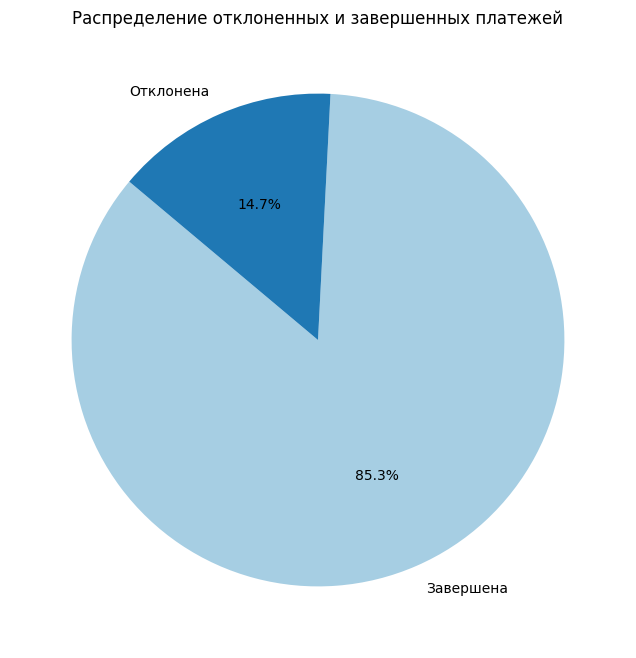

In [46]:
counts = df["status"].value_counts()
    
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title(f'Распределение отклоненных и завершенных платежей')
plt.show()


**Вывод:** 
Мы обработали данные - убрали критичные пропуски, конвертировали валюты, поставили "заглушку" в столбец "aim" (назначение платежа), привели даты к корректному типу. Создали 2 новые колонки - месяц и день недели. Среди всех данных 14.7% - отклоненные платежи. Рекомендуется исследовать причины отклоения, чтобы устраннить препятствия для клиентов. В дальнейшем анализе данные об отклоненных платежах нам не понадобятся. 

## EDA

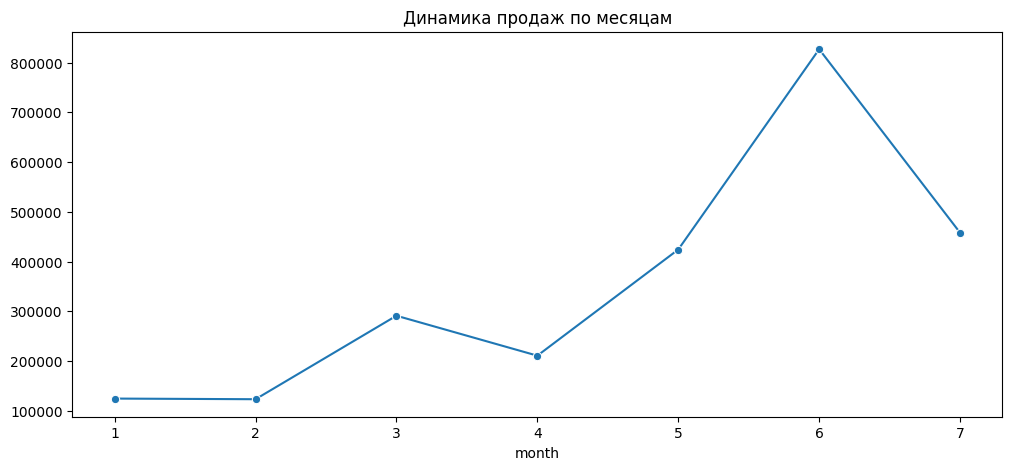

In [49]:
completed_df = converted_df.query('status == "Завершена"')
monthly_sales = completed_df.groupby("month")["final_sum"].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values, marker="o")
plt.title("Динамика продаж по месяцам")
plt.show()

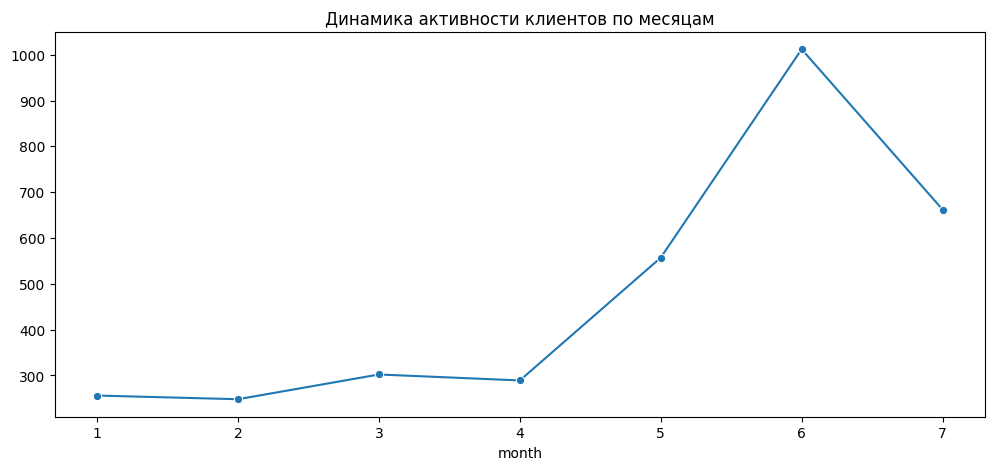

In [50]:
monthly_customer = completed_df.groupby("month")["customer"].count()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_customer.index.astype(str), y=monthly_customer.values, marker="o")
plt.title("Динамика активности клиентов по месяцам")
plt.show()

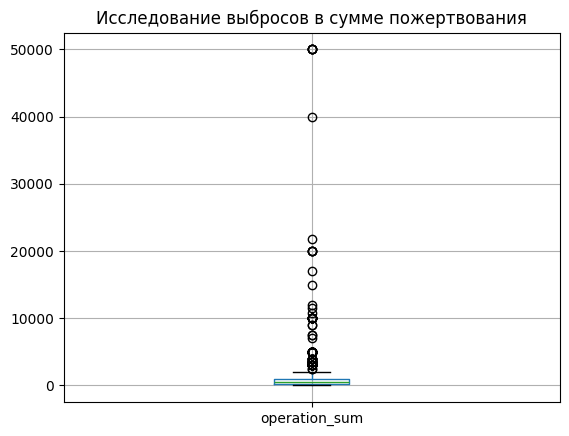

In [51]:
completed_df.boxplot(column=['operation_sum'])
plt.title('Исследование выбросов в сумме пожертвования')
plt.show()

In [52]:
Q1 = completed_df['operation_sum'].quantile(0.25)
Q3 = completed_df['operation_sum'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = completed_df[(completed_df['operation_sum'] >= lower_bound) & (completed_df['operation_sum'] <= upper_bound)]

print(f"Исходный размер: {df.shape[0]}, после очистки: {df_cleaned.shape[0]}")

Исходный размер: 3899, после очистки: 3223


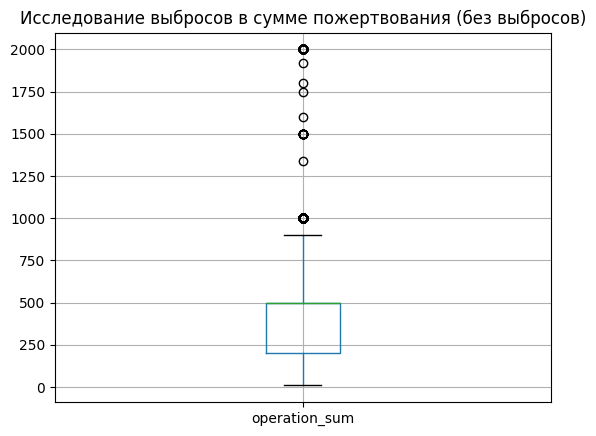

In [53]:
df_cleaned.boxplot(column=['operation_sum'])
plt.title('Исследование выбросов в сумме пожертвования (без выбросов)')
plt.show()

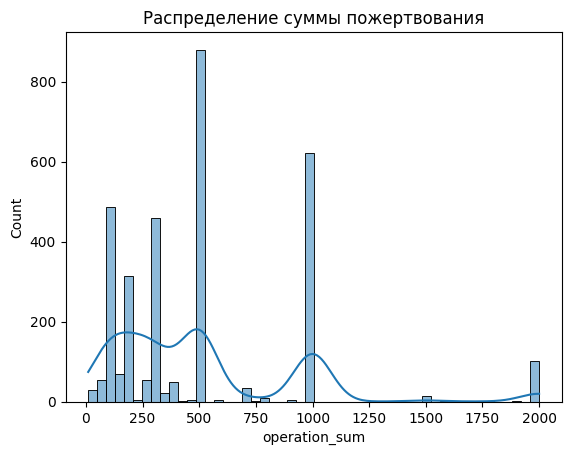

In [54]:
sns.histplot(df_cleaned["operation_sum"], bins=50, kde=True)
plt.title("Распределение суммы пожертвования")
plt.show()

In [55]:
completed_df[['operation_sum']].describe()

,operation_sum
count,3326.000000
mean,763.725797
std,2401.628163
min,10.000000
25%,200.000000
50%,500.000000
75%,1000.000000
max,50000.000000


In [56]:
customer_orders = completed_df.groupby("customer")["id"].count().reset_index()
customer_orders

,customer,id
0,****@bk.ru,1
1,****@de.ru,1
2,****@eml.cc,2
3,****@gksnab.ru,1
4,****@gmail.com,1
...,...,...
1471,zotova.liuda****@yandex.ru,1
1472,zvon****@gmail.com,1
1473,zxc****@yandex.ru,1
1474,zxc2081@yandex.ru,2


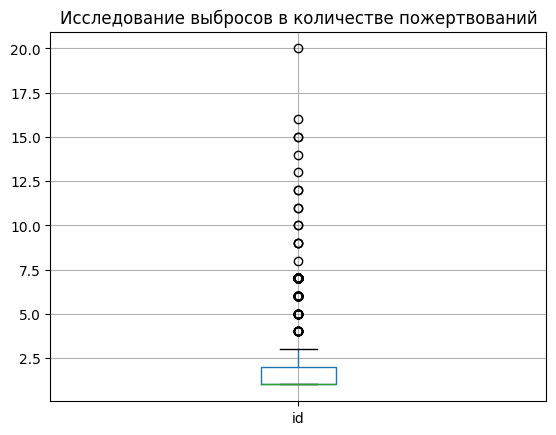

In [57]:
customer_orders.boxplot(column=['id'])
plt.title('Исследование выбросов в количестве пожертвований')
plt.show()

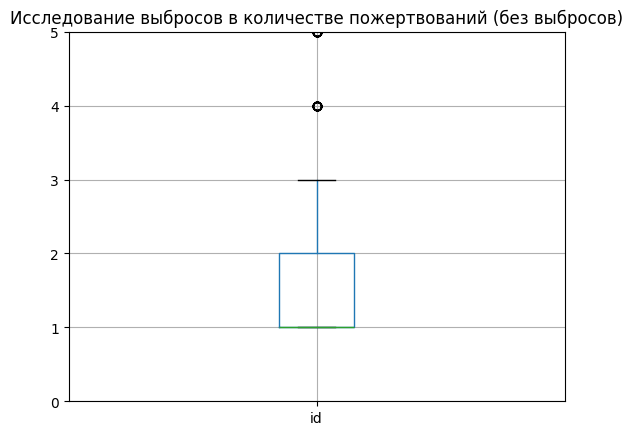

In [58]:
customer_orders.boxplot(column=['id'])
plt.title('Исследование выбросов в количестве пожертвований (без выбросов)')
plt.ylim(0, 5)
plt.show()

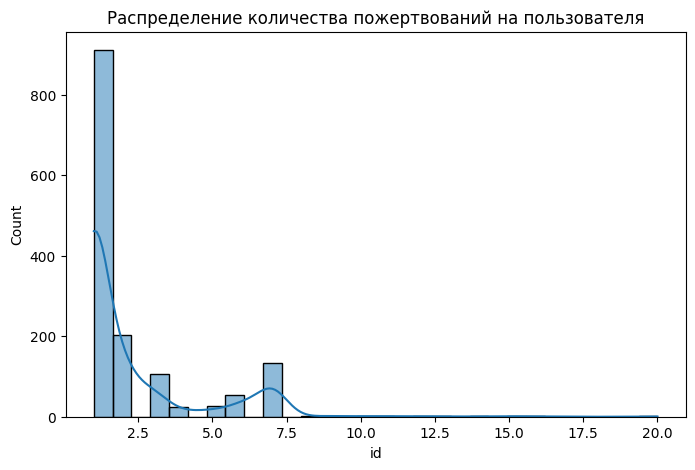

In [59]:
customer_orders = completed_df.groupby("customer")["id"].count()
plt.figure(figsize=(8, 5))
sns.histplot(customer_orders, bins=30, kde=True)
plt.title("Распределение количества пожертвований на пользователя")
plt.show()

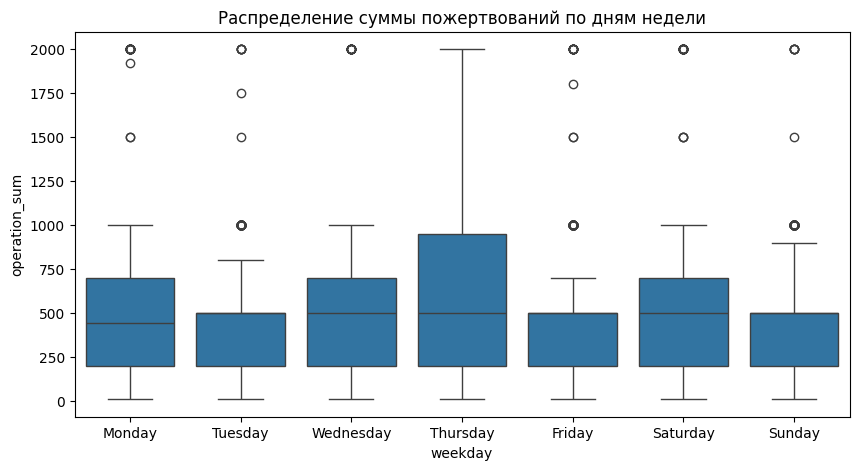

In [60]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="weekday", y="operation_sum", data=df_cleaned, order=[
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])
plt.title("Распределение суммы пожертвований по дням недели")
plt.show()

In [61]:
# топ-15 клиентов по сумме пожертвований
display(completed_df.groupby('customer')['final_sum'].sum().sort_values(ascending=False).nlargest(15))

customer
humblehelptope****@gmail.com    145200.00
Bar-m****@yandex.ru              77440.00
n-sorokina@yandex.ru             49368.00
azat.khali****@gmail.com         48400.00
avito****@hotmail.com            38720.00
jevge****@bk.ru                  33880.00
ket****@mail.ru                  33880.00
holo****@gmail.com               28739.92
hel****@mail.ru                  25168.00
art.ma****@gmail.com             23716.00
gypsytatto****@gmail.com         21054.00
balak****@gmail.com              20328.00
bere****@bk.ru                   19360.00
newpoi****@gmail.com             19360.00
ak****@mail.ru                   18392.00
Name: final_sum, dtype: float64

In [62]:
# топ-15 клиентов по количеству транзакций
display(completed_df.groupby('customer')['id'].count().sort_values(ascending=False).nlargest(15))

customer
morozov****@list.ru             20
bonus.dee****@gmail.com         16
domo****@gmail.com              15
elena.vdowich****@yandex.ru     15
aktov****@mail.ru               14
k_****@inbox.ru                 13
****@yandex.ru                  12
any****@bk.ru                   12
****@mail.ru                    11
u.pro****@gmail.com             11
ak****@mail.ru                  10
elena.zharkov****@inbox.ru      10
l****@mail.ru                    9
victoria.saryc****@gmail.com     9
maria90****@mail.ru              9
Name: id, dtype: int64

**Вывод:**
Динамика продаж как по выручке, так и по количеству транзакций плавно росла от января к апрелю, а в мае и июне уже резко пошла вверх. Но к июлю продажи упали. Вероятно стоит проанализировать причины - изучить какие маркетинговые активности проводились, посмотреть отзывы клиентов. 
В сумме пожертвований есть значительные выбросы - самый большой донат был на сумму 50 000 руб., при среднем чеке - 500 руб. 
Количество взносов тоже имеет выбросы - самое большое количество пожертвований - 20 от одного пользователя. Эти выбросы расположены довольно равномерно по оси и можно предположить, что они могут быть связаны с подписками. В среднем на одного пользователя приходиться от 1 до 2 донатов. 


## RFM

In [65]:
df_completed = df.query('status	== "Завершена"')
max_date = df_completed["action_date"].max() + pd.Timedelta(days=1)

# RFM-анализ
rfm = df_completed.groupby("customer").agg(
    recency=("action_date", lambda x: (max_date - x.max()).days),
    frequency=("customer", "count"),
    monetary=("final_sum", "sum")
)

recency_scores = [5, 4, 3, 2, 1]
frequency_scores = [1, 2, 3, 4, 5]
monetary_scores = [1, 2, 3, 4, 5]

rfm['RecencyScore'] = pd.cut(rfm['recency'], bins=5, labels=recency_scores)
rfm['FrequencyScore'] = pd.cut(rfm['frequency'], bins=5, labels=frequency_scores)
rfm['MonetaryScore'] = pd.cut(rfm['monetary'], bins=5, labels=monetary_scores)

rfm[['RecencyScore', 'FrequencyScore', 'MonetaryScore']] = rfm[['RecencyScore', 'FrequencyScore', 'MonetaryScore']].astype(int)

rfm['RFM_Score'] = rfm['RecencyScore'] + rfm['FrequencyScore'] + rfm['MonetaryScore']

segment_labels = ['Low-Value', 'Mid-Value', 'High-Value']
rfm['RFM_Segment'] = pd.qcut(rfm['RFM_Score'], q=3, labels=segment_labels)


In [66]:
# разбиваем клиентов по 4 категориям
rfm['segment'] = ''

rfm.loc[rfm['RFM_Score'] >= 8, 'segment'] = 'Лучшие клиенты'
rfm.loc[(rfm['RFM_Score'] >= 6) & (rfm['RFM_Score'] < 8), 'segment'] = 'Потенциально лояльные'
rfm.loc[(rfm['RFM_Score'] >= 5) & (rfm['RFM_Score'] < 6), 'segment'] = 'Клиенты, подверженные риску'
rfm.loc[(rfm['RFM_Score'] >= 4) & (rfm['RFM_Score'] < 5), 'segment'] = "Можем потерять"
rfm.loc[(rfm['RFM_Score'] >= 3) & (rfm['RFM_Score'] < 4), 'segment'] = "Потеряные"

In [67]:
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['segment_client', 'count']
segment_counts

,segment_client,count
0,Потенциально лояльные,1151
1,Лучшие клиенты,226
2,"Клиенты, подверженные риску",43
3,Можем потерять,39
4,Потеряные,17


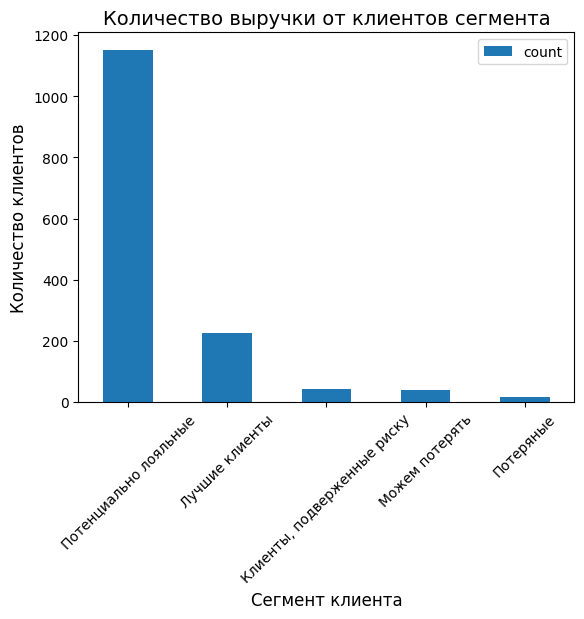

In [68]:
segment_counts.plot(kind='bar', x='segment_client', y='count')
plt.xticks(rotation=45)
plt.title('Количество выручки от клиентов сегмента',size=14)
plt.xlabel('Сегмент клиента',size=12)
plt.ylabel('Количество клиентов',size=12)
plt.show()

In [69]:
df_completed = df_completed.merge(rfm[["segment"]], on="customer", how="left")

In [70]:
df_completed.head()

,id,action_date,bank,site,order_id,customer,type,operation_sum,operation_currency,comission_sum,final_sum,final_currency,status,aim,comission_perc,file,month,weekday,segment
0,2127167350,2024-07-31 21:34:00,Тинькофф,prostieveschi.ru,23626,marina.****@gmail.com,Оплата,2000,RUB,64.0,1936.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,Потенциально лояльные
1,2127156836,2024-07-31 20:18:00,Тинькофф,prostieveschi.ru,<NA>,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,Лучшие клиенты
2,2127125589,2024-07-31 16:55:00,Тинькофф,prostieveschi.ru,<NA>,Ekhisa****@gmail.com,Регулярная оплата,1000,RUB,32.0,968.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,Потенциально лояльные
3,2127122975,2024-07-31 16:36:00,Тинькофф,prostieveschi.ru,23623,Slonop****@list.ru,Оплата,7500,RUB,240.0,7260.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,Потенциально лояльные
4,2127097779,2024-07-31 13:57:00,Тинькофф,prostieveschi.ru,<NA>,lenalenova****@gmail.com,Регулярная оплата,500,RUB,16.0,484.0,RUB,Завершена,"Поддержите ""Простые вещи""",3.2,июль.xls,7,Wednesday,Потенциально лояльные


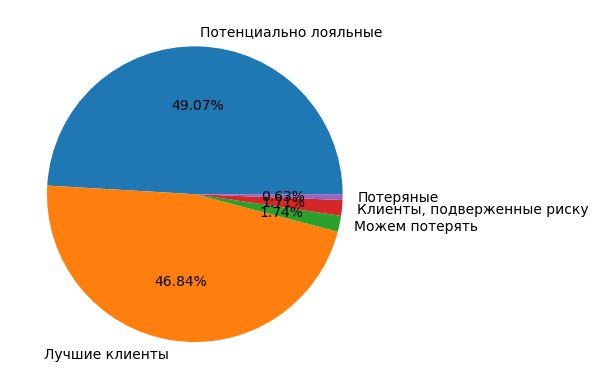

In [71]:
d_pie = df_completed['segment'].value_counts()
plt.pie(d_pie, labels=d_pie.index, autopct='%.2f%%')
plt.show()

In [72]:
pivot_segment = df_completed.reset_index().groupby('segment').agg(
    {'customer': 'nunique', 'id': 'nunique', 'operation_sum' : 'sum', 'final_sum': 'sum'}
).reset_index()
pivot_segment.rename(columns={'customer': 'count_customers', 
                          'id': 'count_transaction'}, inplace=True)

pivot_segment['AOV'] = round(pivot_segment['operation_sum']/pivot_segment['count_customers'], 2)
pivot_segment['mean_orders'] = round(pivot_segment['count_transaction']/pivot_segment['count_customers'], 2)
pivot_segment

,segment,count_customers,count_transaction,operation_sum,final_sum,AOV,mean_orders
0,"Клиенты, подверженные риску",43,57,67060,64905.60,1559.53,1.33
1,Лучшие клиенты,226,1558,1091652,1056372.29,4830.32,6.89
2,Можем потерять,39,58,29080,28147.34,745.64,1.49
3,Потенциально лояльные,1151,1632,1344360,1301145.27,1167.99,1.42
4,Потеряные,17,21,8000,7741.20,470.59,1.24


**Вывод:**
Мы разделили клиентов на сегменты с помощью RFM-анализа. Получились, следующие сегменты:

1. Лучшие клиенты (46.84%) - покупают много и часто. У этих клиентов большой чек и количество заказов.

2. Перспективно лояльные (49.07%) - это клиенты, которые покупали довольно много и часто, поэтому нужно постараться удержать их интерес здесь и сейчас, выяснить его пожелания, потребности и интересы. Пришли недавно, поэтому нужно их удерживать. 

3. Клиенты, подверженные риску (1.71%)- клиенты, которые постепенно теряют интерес к проекту. Можно предложить им долгосрочную мотивацию, например, бонусы или программу лояльности. Напомнить, что наш продукт лучше других.

4. Под угрозой оттока (1.74%)- эти клиенты более перспективные, чем потерянные, но всё-таки уже на грани. Они покупали много раз и/или на большую сумму, но делали это давно. Ценность таких клиентов для вас не столько в их возвращении, сколько в выяснении причины, по которой они ушли от вас.

5. Потерянные клиенты (0.63%)- можно попробовать их вернуть, попытка не пытка. Но работать с ними лучше, когда уже решили вопросы с основными сегментами, если остались силы, время и ресурс.

Можно сделать вывод, что клиентская база удачно сформирована и доля теряющих интерес клиентов менее 5%. 

## Когортный анализ

In [75]:
df_completed["cohort"] = df_completed.groupby("customer")["action_date"].transform("min").dt.to_period("M")
df_completed["cohort_month"] = df_completed["action_date"].dt.to_period('M')
df_completed["month_life"] = (df_completed["cohort_month"] - df_completed["cohort"]).apply(lambda x: x.n)

# Метрики: удержание, средний чек, LTV
cohort_size = df_completed.groupby('cohort')['customer'].nunique()
cohort_retention = df_completed.groupby(['cohort', 'month_life'])['customer'].nunique().unstack(0).divide(cohort_size, axis=1)
cohort_avg_check = df_completed.groupby(['cohort', 'month_life'])['final_sum'].mean().unstack(0)
cohort_ltv = df_completed.groupby(['cohort', 'month_life'])['final_sum'].sum().unstack(0).cumsum()

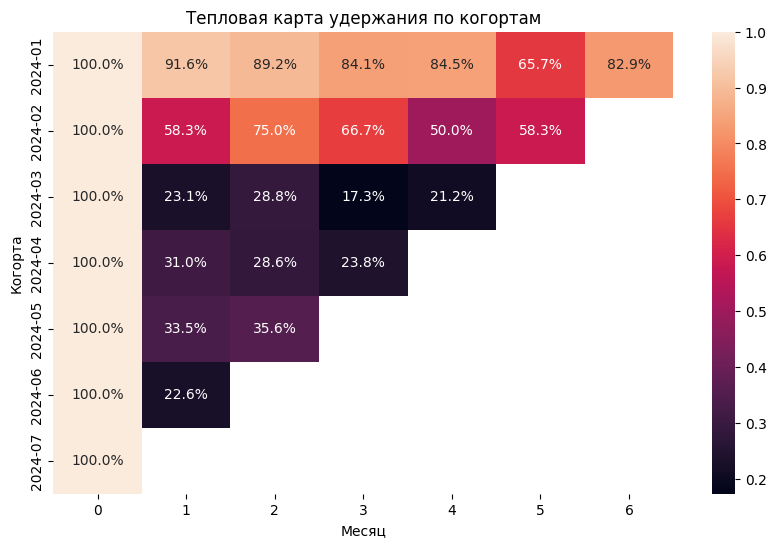

In [76]:
# Визуализация: тепловая карта удержания
plt.figure(figsize=(10, 6))
sns.heatmap(cohort_retention.T, annot=True, fmt='.1%')
plt.title('Тепловая карта удержания по когортам')
plt.ylabel('Когорта')
plt.xlabel('Месяц')
plt.show()

Новые пользователи проявляют значительный интерес к сервису в первый месяц, что говорит о хорошем первом впечатлении. Хотя первоначальное удержание высокое, оно быстро снижается. Это указывает на необходимость работы над удержанием пользователей на более поздних этапах взаимодействия.\
Можно рассмотреть следующие шаги:
- Повышение качества обслуживания.
- Создание программ лояльности или повторных покупок.
- Регулярные коммуникации с пользователями через email-рассылки или push-уведомления.
  
Сезонные факторы:\
Наблюдаемый рост удержания в 6-м месяце для некоторых когорт может быть связан с сезонными событиями. Это стоит учитывать при планировани  маркетинговых кампаний

Лояльность старых пользователей:\
Старые когорты демонстрируют стабильное, хотя и низкое, удержание. Это указывает на наличие лояльной части аудитории, которую важно поддерживать и развива...

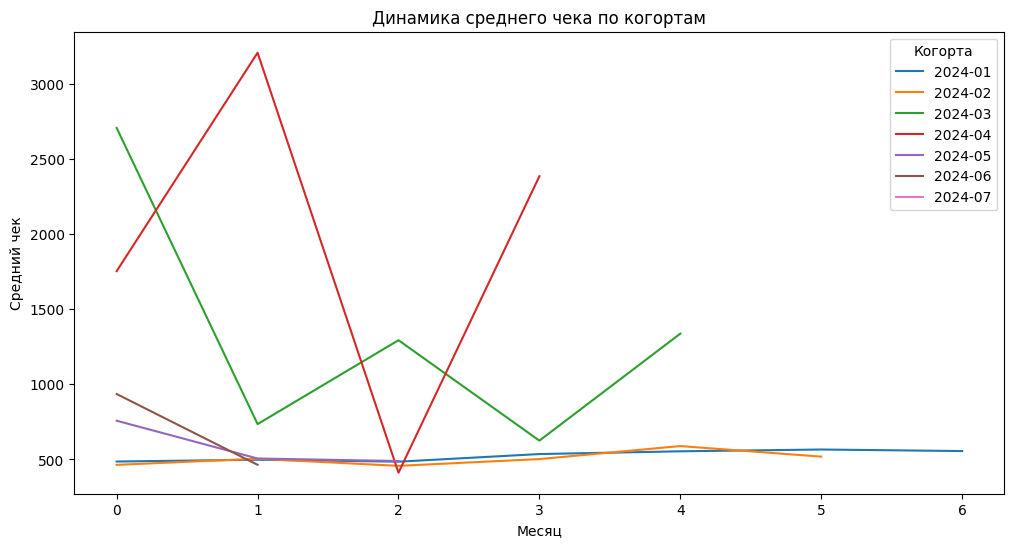

In [78]:
# Визуализация: линейный график динамики среднего чека
plt.figure(figsize=(12, 6))
for cohort in cohort_avg_check.columns:
    plt.plot(cohort_avg_check.index, cohort_avg_check[cohort], label=str(cohort))
plt.legend(title='Когорта')
plt.title('Динамика среднего чека по когортам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.show()

Некоторые когорты демонстрируют значительные средние чеки в первый месяц. Это может быть связано с тем, что пользователи совершают крупные покупки сразу после регистрации, возможно, под влиянием рекламных акций или специальных предложений. Хотя первоначальные средние чеки высоки, они быстро снижаются. Это указывает на необходимость работы над удержанием интереса пользователей и стимулированием повторных покупок с более высокой стоимостью. Резкие скачки среднего чека могут быть связаны с сезонными акциями или событиями. Это стоит учитывать при планировании маркетинговых кампаний.\
Резкие скачки в первом месяце для когорт 2024-03 и 2024-04, вероятно, связаны с маркетинговыми акциями, специальными предложениями или распространением дорогих товаров.
Необходимо проанализировать успешность этих мероприятий и рассмотреть возможность их повторения для будущих когорт
.
Значительное снижение среднего чека после первого месяца является нормальным явлением для многих когорт. Однако его скорость и масштаб требуют внимания:
Если снижение происходит слишком быстро, это может указывать на отсутствие постоянных стимулов для крупных покуп
ок.
Необходимо разработать стратегию, чтобы поддерживать интерес пользователей к более дорогим товарам даже после окончания ак
ций.
Для когорт, в которых средний чек стабильно низкий (например, 2024-01 и 2024-02), важно проанализировать целевую аудиторию и маркетинговые стратегии:
Возможно, требуется пересмотреть ценовую политику или ассортимент продукции для этой группы пользова
телей.
Необходимо убедиться, что все когорты получают достаточные стимулы для совершения покупок.

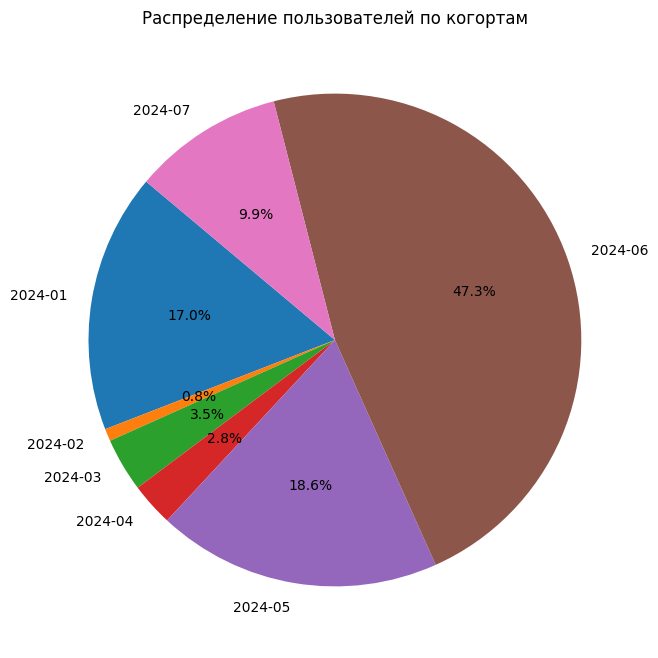

In [80]:
# Визуализация: круговая диаграмма распределения пользователей по когортам
cohort_distribution = cohort_size / cohort_size.sum()
plt.figure(figsize=(8, 8))
plt.pie(cohort_distribution, labels=cohort_distribution.index.astype(str), autopct='%1.1f%%', startangle=140)
plt.title('Распределение пользователей по когортам')
plt.show()

In [81]:
cohort_size

cohort
2024-01    251
2024-02     12
2024-03     52
2024-04     42
2024-05    275
2024-06    698
2024-07    146
Freq: M, Name: customer, dtype: int64

Распределение пользователей по когортам крайне неравномерно. Большинство пользователей сосредоточены в нескольких крупных когортах, особенно в самой большой когорте 06.2024 (49.6%). Это может быть связано с успешной маркетинговой кампанией или другим фактором, который привлек большое количество пользователей в этот период.

Поскольку большая часть пользователей приходится на несколько крупных когорт 06.2024, 01.2024, 07.2024, анализ их поведения будет иметь решающее значение для понимания общих тенденций. Меньшие когорты (02.2024, 03.2024, 03.2024) имеют незначительный вес в общей структуре пользователей. Однако их анализ может быть важен для выявления специфических трендов или проблем, связанных с привлечением пользователей в эти периоды.

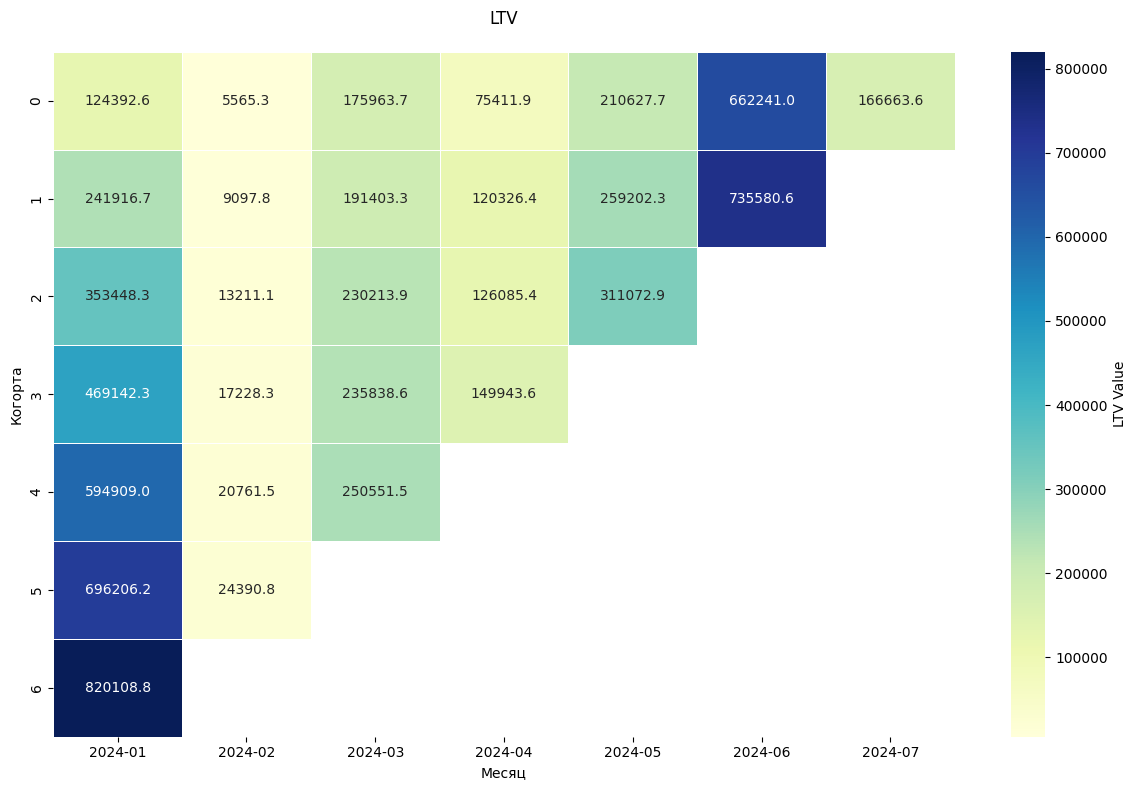

In [83]:
# LTV
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_ltv, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'LTV Value'})
plt.title('LTV', pad=20)
plt.xlabel('Месяц')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

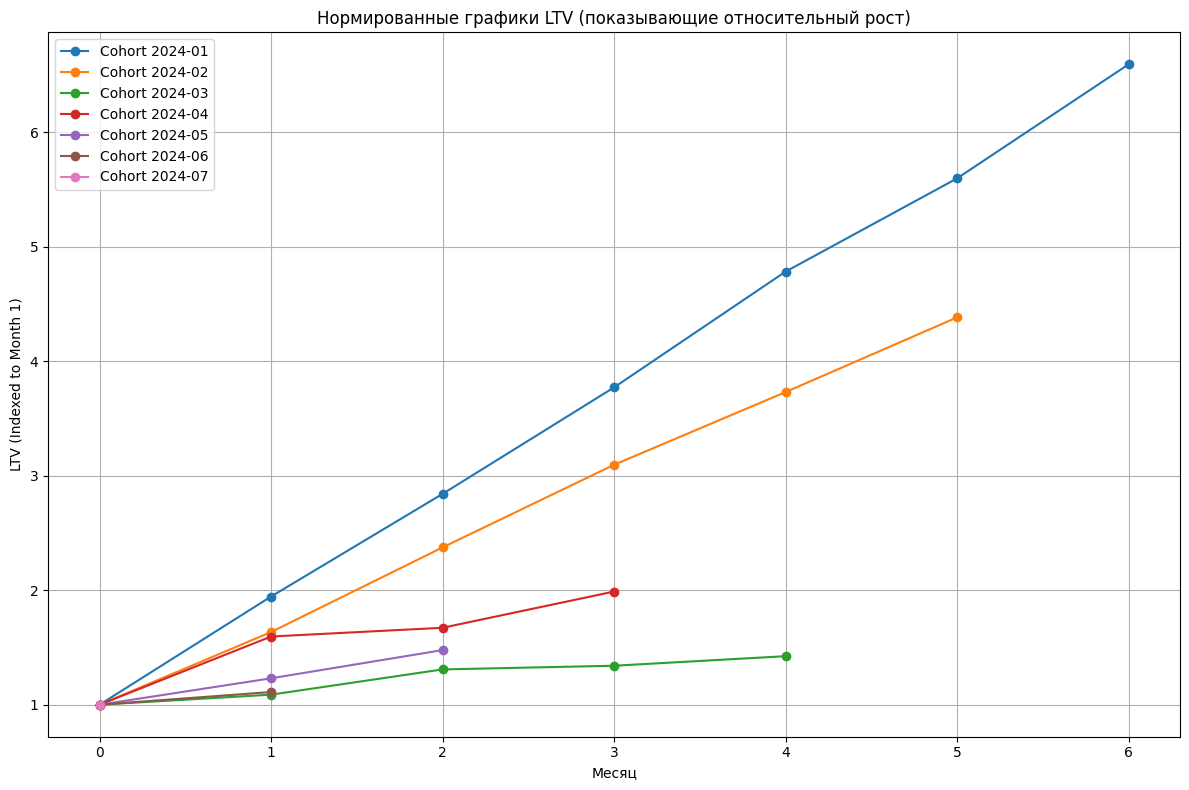

In [84]:
plt.figure(figsize=(12, 8))
for cohort in cohort_ltv.columns:
    values = cohort_ltv[cohort].values
    first_value = values[0]
    if not np.isnan(first_value):
        plt.plot(cohort_ltv.index, values / first_value, marker='o', label=f'Cohort {cohort}')
        
plt.title('Нормированные графики LTV (показывающие относительный рост)')
plt.xlabel('Месяц')
plt.ylabel('LTV (Indexed to Month 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Когорта 2024-01 демонстрирует наиболее значительный относительный рост LTV.
Когорты, начавшиеся позже (например, 2024-06 и 2024-07), демонстрируют низкий или нулевой относительный рост.

Хотя начальный LTV высок, он быстро снижается или достигает плато. Это указывает на необходимость работы над удержанием пользователей и стимулированием повторных покупок для увеличения их долгосрочной ценности
.
Резкие скачки LTV могут быть связаны с сезонными акциями или событиями. Это стоит учитывать при планировании маркетинговых кампани
й.
Старые когорты демонстрируют относительно стабильный LTV, хотя он не всегда растёт. Это указывает на то, что постоянные пользователи продолжают приносить доход, но их активность может быть ниже по сравнению с новыми пользователя

Когорты, начавшие раньше, имеют более высокие начальные значения LTV и демонстрируют более быстрый рост.
Со временем рост LTV замедляется или стабилизируется для всех когорт
.т.

Необходимо уделять внимание ранним когортам, так как они демонстрируют наибольший потенциал рост
а LTV.
Для новых когорт требуется усиление маркетинговых и продуктовых стратегий для стимулирования рос
та LTV.
Мониторинг временной динамики LTV поможет оптимизировать ресурсы и инвестиции в различные когорты.ми.

## Маркетинговый анализ

In [87]:
df_completed["site"].unique()

array(['prostieveschi.ru'], dtype=object)

В данных указан только один источник клиентов - сайт проекта. И нет информации о рекламных компаниях или акциях. Поэтому мы не можем провести полноценный анализ эффекивности маркетинга. 

In [89]:
# Анализ DAU, WAU, MAU, sticky factor

df_completed['date'] = pd.to_datetime(df_completed['action_date'])

# Извлекаем месяц, неделю и дату
df_completed['first_month'] = df_completed['date'].dt.month
df_completed['first_week'] = df_completed['date'].dt.isocalendar().week
df_completed['first_date'] = df_completed['action_date'].dt.date

# Преобразуем first_date в datetime, чтобы использовать resample()
df_completed['first_date'] = pd.to_datetime(df_completed['first_date'])

# Вычисляем DAU, WAU, MAU
dau_series = df_completed.groupby('first_date')['customer'].nunique()
dau = dau_series.mean()
wau = df_completed.groupby('first_week')['customer'].nunique().mean()
mau = df_completed.groupby('first_month')['customer'].nunique().mean()

# Sticky factor (нужно убедиться, что индекс - DatetimeIndex)
dau_series.index = pd.to_datetime(dau_series.index)

sticky_wau = (dau_series.resample("W").mean() / wau).mean()
sticky_mau = (dau_series.resample("M").mean() / mau).mean()

# Вывод результатов
print(f"DAU: {dau:.2f}")
print(f"WAU: {wau:.2f}")
print(f"MAU: {mau:.2f}")
print(f"Средний Sticky Factor WAU: {sticky_wau:.2f}")
print(f"Средний Sticky Factor MAU: {sticky_mau:.2f}")

DAU: 15.62
WAU: 105.16
MAU: 456.14
Средний Sticky Factor WAU: 0.15
Средний Sticky Factor MAU: 0.03


**1. Активность пользователей (DAU, WAU, MAU)**  
- **DAU (Daily Active Users) = 15.62**  
  - В день магазин посещает **~16 уникальных пользователей**.  
- **WAU (Weekly Active Users) = 105.16**  
  - В неделю — **~105 пользователей** (среднедневная активность согласуется с DAU).  
- **MAU (Monthly Active Users) = 456.14**  
  - В месяц — **~456 пользователей**, что подтверждает стабильность DAU.  

**Вывод:**  
Аудитория небольшая, но активность **стабильна**. Нет резких колебаний, но и роста не наблюдается.  

---

**2. Показатели удержания (Retention)**  
- **Недельное удержание (WAU Retention) = 15%**  
  - Только **15 из 100 пользователей** возвращаются через неделю.  
- **Месячное удержание (MAU Retention) = 3%**  
  - Через месяц остаются лишь **3%** от исходной аудитории.  

**Вывод:**  
- **Критически низкое удержание** — большинство пользователей уходит после первого визита.  
- Возможные причины:  
  - Нет мотивации для повторных посещений (нет акций, персональных предложений).  
  - Ограниченный ассортимент или слабая коммуникация (например, нет напоминаний через email/sms).  
  - Пользователи воспринимают магазин как «разовую точку» (например, только для сдачи вещей).  

---

**3. Рекомендации**  
**Удержание пользователей**  
- Внедрить **программу лояльности** (скидки за повторные покупки, бонусы за донации).  
- Настроить **автоматические напоминания** (о новых поступлениях, акциях).  
- Добавить **персонализацию** (рекомендации на основе прошлых покупок).  

**Рост активности**  
- Запустить **еженедельные акции** (например, «Скидка 20% в первую пятницу месяца»).  
- Активнее использовать **соцсети** (анонсы мероприятий, истории доноров/покупателей).  

**Глубокий анализ**  
- Провести **опросы** для ушедших пользователей (почему не вернулись?).  
- Проанализировать **воронку продаж** (на каком этапе теряются клиенты?).  

---

**Итоговый вывод**  
Магазин стабильно привлекает **~15 пользователей в день**, но **не удерживает их**.  
**Ключевая проблема** — отсутствие стратегии работы с повторной аудиторией.  
**Приоритет:** повышение Retention через систему вовлечения и обратную связь от клиентов.  

# Выводы

1) **Предобработка данных:** Мы обработали данные - убрали критичные пропуски, конвертировали валюты, поставили "заглушку" в столбец "aim" (назначение платежа), привели даты к корректному типу. Создали 2 новые колонки - месяц и день недели. Среди всех данных 14.7% - отклоненные платежи. Рекомендуется исследовать причины отклоения, чтобы устраннить препятствия для клиентов. В дальнейшем анализе данные об отклоненных платежах нам не понадобятся.
   
2) **EDA:** Динамика продаж как по выручке, так и по количеству транзакций плавно росла от января к апрелю, а в мае и июне уже резко пошла вверх. Но к июлю продажи упали. Вероятно стоит проанализировать причины - изучить какие маркетинговые активности проводились, посмотреть отзывы клиентов. В сумме пожертвований есть значительные выбросы - самый большой донат был на сумму 50 000 руб., при среднем чеке - 500 руб. Количество взносов тоже имеет выбросы - самое большое количество пожертвований - 20 от одного пользователя. Эти выбросы расположены довольно равномерно по оси и можно предположить, что они могут быть связаны с подписками. В среднем на одного пользователя приходиться от 1 до 2 донатов.
   
3) **RFM:**
   - Лучшие клиенты (46.84%) - покупают много и часто. У этих клиентов большой чек и количество заказов.

   - Перспективно лояльные (49.07%) - это клиенты, которые покупали довольно много и часто, поэтому нужно постараться удержать их интерес здесь и сейчас, выяснить его пожелания, потребности и интересы. Пришли недавно, поэтому нужно их удерживать.

   - Клиенты, подверженные риску (1.71%)- клиенты, которые постепенно теряют интерес к проекту. Можно предложить им долгосрочную мотивацию, например, бонусы или программу лояльности. Напомнить, что наш продукт лучше других.

   - Под угрозой оттока (1.74%)- эти клиенты более перспективные, чем потерянные, но всё-таки уже на грани. Они покупали много раз и/или на большую сумму, но делали это давно. Ценность таких клиентов для вас не столько в их возвращении, сколько в выяснении причины, по которой они ушли от вас.

   - Потерянные клиенты (0.63%)- можно попробовать их вернуть, попытка не пытка. Но работать с ними лучше, когда уже решили вопросы с основными сегментами, если остались силы, время и ресурс.

   Можно сделать вывод, что клиентская база удачно сформирована и доля теряющих интерес клиентов менее 5%.

4) **Когортный анализ:**
Новые пользователи проявляют значительный интерес к сервису в первый месяц, что говорит о хорошем первом впечатлении. Хотя первоначальное удержание высокое, оно быстро снижается. Это указывает на необходимость работы над удержанием пользователей на более поздних этапах взаимодействия.\

Сезонные факторы:\
Наблюдаемый рост удержания в 6-м месяце для некоторых когорт может быть связан с сезонными событиями. Это стоит учитывать при планировани  маркетинговых кампаний

Лояльность старых пользователей:\
Старые когорты демонстрируют стабильное, хотя и низкое, удержание. Это указывает на наличие лояльной части аудитории, которую важно поддерживать и развивать.

Некоторые когорты демонстрируют значительные средние чеки в первый месяц. Это может быть связано с тем, что пользователи совершают крупные покупки сразу после регистрации, возможно, под влиянием рекламных акций или специальных предложений. Хотя первоначальные средние чеки высоки, они быстро снижаются. Это указывает на необходимость работы над удержанием интереса пользователей и стимулированием повторных покупок с более высокой стоимостью. Резкие скачки среднего чека могут быть связаны с сезонными акциями или событиями. Это стоит учитывать при планировании маркетинговых кампаний.\
Резкие скачки в первом месяце для когорт 2024-03 и 2024-04, вероятно, связаны с маркетинговыми акциями, специальными предложениями или распространением дорогих товаров.
Необходимо проанализировать успешность этих мероприятий и рассмотреть возможность их повторения для будущих когорт.

Распределение пользователей по когортам крайне неравномерно. Большинство пользователей сосредоточены в нескольких крупных когортах, особенно в самой большой когорте 06.2024 (49.6%). Это может быть связано с успешной маркетинговой кампанией или другим фактором, который привлек большое количество пользователей в этот период.

Поскольку большая часть пользователей приходится на несколько крупных когорт 06.2024, 01.2024, 07.2024, анализ их поведения будет иметь решающее значение для понимания общих тенденций. Меньшие когорты (02.2024, 03.2024, 03.2024) имеют незначительный вес в общей структуре пользователей. Однако их анализ может быть важен для выявления специфических трендов или проблем, связанных с привлечением пользователей в эти периоды.

5) **Маркетинговый анализ:**
В данных указан только один источник клиентов - сайт проекта. И нет информации о рекламных компаниях или акциях. Поэтому мы не можем провести полноценный анализ эффекивности маркетинга.

Магазин стабильно привлекает ~15 пользователей в день, но не удерживает их.  
Ключевая проблема — отсутствие стратегии работы с повторной аудиторией.  
Приоритет: повышение Retention через систему вовлечения и обратную связь от клиентов.  

In [93]:
converted_df.to_csv(r"C:/Users/Алина/Desktop/st/df_st.csv", index=False, encoding='utf-8')
df_completed.to_csv(r"C:/Users/Алина/Desktop/st/df_completed_st.csv", index=False, encoding='utf-8')

https://datalens.yandex.cloud/2172nq47t958o-analiticheskaya-panel